# Задание Ultra Pro

Используя базу "Пассажиры автобуса", подготовьте данные для обучения нейронной сети, классифицирующей изображение на два класса:
- входящий пассажир
- выходящий пассажир

Цель: добиться точности на проверочной выборке не ниже 85%.


In [1]:
import os
import zipfile

import gdown
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split

%matplotlib inline

# Фиксируем случайность
SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)


In [2]:
# распаковка базы
DATA_URL = 'https://storage.yandexcloud.net/aiueducation/Content/base/l4/bus.zip'
ARCHIVE_NAME = 'bus.zip'
BASE_DIR = '/content'

if not os.path.exists(ARCHIVE_NAME):
    gdown.download(DATA_URL, ARCHIVE_NAME, quiet=True)

# Распаковка архива без запроса подтверждения при повторном запуске
with zipfile.ZipFile(ARCHIVE_NAME, 'r') as archive:
    archive.extractall(BASE_DIR)

print('База загружена')


База загружена


In [3]:
class BusPassenger:
    def __init__(self, epochs=40, batch_size=32, img_height=120, img_width=80):
        self.epochs = epochs
        self.batch_size = batch_size
        self.img_height = img_height
        self.img_width = img_width
        self.class_names = ['Входящий', 'Выходящий']
        self.class_to_label = {'Входящий': 0, 'Выходящий': 1}

    # загрузка изображений из папок
    def load_dataset(self):
        x_data = []
        y_data = []

        for class_name in self.class_names:
            class_dir = os.path.join(BASE_DIR, class_name)

            if not os.path.isdir(class_dir):
                raise FileNotFoundError(f'Папка не найдена: {class_dir}')

            for file_name in sorted(os.listdir(class_dir)):
                img_path = os.path.join(class_dir, file_name)

                if not os.path.isfile(img_path):
                    continue

                try:
                    img = tf.keras.utils.load_img(
                        img_path,
                        target_size=(self.img_height, self.img_width),
                        color_mode='grayscale'
                    )
                    img_array = tf.keras.utils.img_to_array(img)
                    x_data.append(img_array)
                    y_data.append(self.class_to_label[class_name])
                except Exception as error:
                    print('Файл пропущен:', img_path, error)

        x_data = np.array(x_data, dtype='float32') / 255.0
        y_data = np.array(y_data, dtype='int64')

        print('Размер x_data:', x_data.shape)
        print('Размер y_data:', y_data.shape)
        print('Количество по классам:', np.unique(y_data, return_counts=True))

        return x_data, y_data

    # разбиение на обучающую, проверочную, тестовую выборки
    def load_data(self):
        x_data, y_data = self.load_dataset()

        x_train_val, x_test, y_train_val, y_test = train_test_split(
            x_data,
            y_data,
            test_size=0.2,
            random_state=SEED,
            stratify=y_data
        )

        x_train, x_val, y_train, y_val = train_test_split(
            x_train_val,
            y_train_val,
            test_size=0.25,
            random_state=SEED,
            stratify=y_train_val
        )

        return x_train, y_train, x_val, y_val, x_test, y_test

    # создание модели
    def create_model(self):
        model = Sequential([
            Input(shape=(self.img_height, self.img_width, 1)),
            Flatten(),
            Dense(256, activation='relu'),
            Dropout(0.25),
            Dense(64, activation='relu'),
            Dense(2, activation='softmax')
        ])

        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        return model

    # обучение модели
    def train_model(self):
        x_train, y_train, x_val, y_val, x_test, y_test = self.load_data()
        model = self.create_model()

        callbacks = [
            EarlyStopping(
                monitor='val_loss',
                patience=5,
                restore_best_weights=True
            ),
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=2,
                min_lr=1e-6
            )
        ]

        history = model.fit(
            x_train,
            y_train,
            epochs=self.epochs,
            batch_size=self.batch_size,
            validation_data=(x_val, y_val),
            callbacks=callbacks,
            shuffle=True,
            verbose=1
        )

        test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

        return model, history, test_loss, test_accuracy

    # построение графиков
    def plot_history(self, history):
        plt.figure(figsize=(14, 5))

        plt.subplot(1, 2, 1)
        plt.plot(history.history['loss'], label='ошибка обучения')
        plt.plot(history.history['val_loss'], label='ошибка проверки')
        plt.title('График ошибки')
        plt.xlabel('Эпоха')
        plt.ylabel('Ошибка')
        plt.legend()
        plt.grid(True)

        plt.subplot(1, 2, 2)
        plt.plot(history.history['accuracy'], label='точность обучения')
        plt.plot(history.history['val_accuracy'], label='точность проверки')
        plt.title('График точности')
        plt.xlabel('Эпоха')
        plt.ylabel('Точность')
        plt.legend()
        plt.grid(True)

        plt.show()


In [4]:
bus_model = BusPassenger(epochs=40, batch_size=32)
model, history, loss, accuracy = bus_model.train_model()

print('Ошибка на тестовой выборке:', loss)
print('Точность на тестовой выборке:', accuracy)


Размер x_data: (9081, 120, 80, 1)
Размер y_data: (9081,)
Количество по классам: (array([0, 1]), array([6485, 2596]))
Epoch 1/40
171/171 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.6676 - loss: 0.7815 - val_accuracy: 0.7307 - val_loss: 0.5670 - learning_rate: 0.0010
Epoch 2/40
171/171 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - accuracy: 0.7098 - loss: 0.5840 - val_accuracy: 0.7373 - val_loss: 0.5566 - learning_rate: 0.0010
Epoch 3/40
171/171 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.7160 - loss: 0.5655 - val_accuracy: 0.7280 - val_loss: 0.5443 - learning_rate: 0.0010
Epoch 4/40
171/171 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.7173 - loss: 0.5632 - val_accuracy: 0.7230 - val_loss: 0.5507 - learning_rate: 0.0010
Epoch 5/40
171/171 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.7355 - loss: 0.5510 - val_accuracy: 0.7252 - val_loss: 0.5335 - learning_rate: 0.0010
Epoch 6/40
171/171 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.7305 - loss: 0.5455 - val_accuracy: 0.7417 - val_l

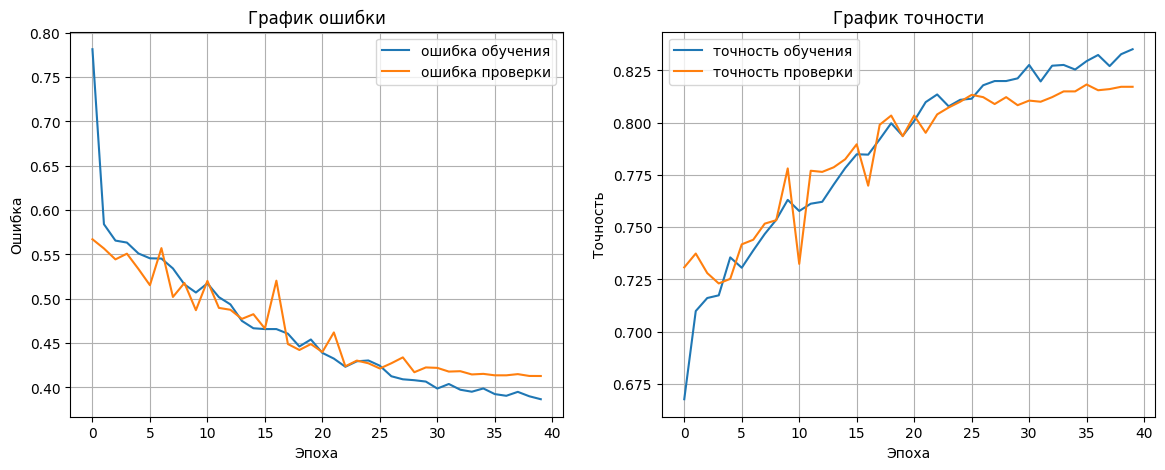

In [5]:
bus_model.plot_history(history)
